In [1]:
import numpy as np
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [12]:
(X_train,_),(_,_) = tf.keras.datasets.fashion_mnist.load_data()
X_train = X_train.astype('float32')/255.0
X_train = np.reshape(X_train, (-1,28,28,1))

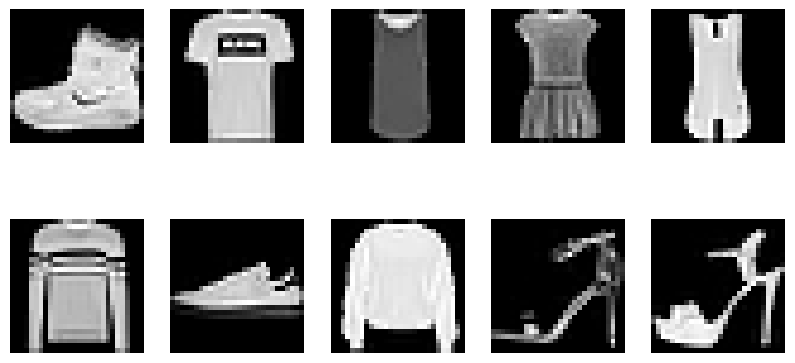

In [13]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

# Build Generator

In [ ]:
latend_dim = 100 

generator = keras.Sequential([              
    layers.Dense(7*7*128, input_dim=(latend_dim)),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7,7,128)),

    layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same')
])

generator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 6272)              633472    
                                                                 
 batch_normalization_2 (Batc  (None, 6272)             25088     
 hNormalization)                                                 
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 6272)              0         
                                                                 
 reshape_1 (Reshape)         (None, 7, 7, 128)         0         
                                                                 
 conv2d_transpose_2 (Conv2DT  (None, 14, 14, 64)       131136    
 ranspose)                                                       
                                                                 
 batch_normalization_3 (Batc  (None, 14, 14, 64)      

# Build Discriminator

In [ ]:
discriminator = keras.Sequential([
    layers.Input(shape=(28,28,1)),    # 128 - 64 -1 

    layers.Conv2D(64, kernel_size=4, strides=2, padding='same'),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1,activation='sigmoid')
])

discriminator.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        1088      
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 14, 14, 64)        0         
                                                                 
 dropout_1 (Dropout)         (None, 14, 14, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 128)         131200    
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 7, 7, 128)         0         
                                                                 
 dropout_2 (Dropout)         (None, 7, 7, 128)         0         
                                                                 
 flatten (Flatten)           (None, 6272)             

### Compile Discriminator

In [19]:
discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy', 
    metrics = ['accuracy']
)

### Combine GAN

In [20]:
discriminator.trainable=False 

gan_input = keras.Input(shape=(latend_dim))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)

gan = keras.Model(gan_input, gan_output)

gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy', 
    metrics = ['accuracy']
)

### Train GAN

In [22]:
epochs = 5000
batch_size = 128 

for epoch in range(epochs):

    idx = np.random.randint(0,X_train.shape[0], batch_size)
    real_images = X_train[idx] 

    noise = np.random.normal(0,1,(batch_size,latend_dim))
    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size,1)))

    # generator 
    noise = np.random.normal(0,1,(batch_size,latend_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 1000 == 0:
        print(
            f"Epoch: {epoch} |",
            f"D_loss: {d_loss_real[0]:.4f} |",
            f"G Loss: {g_loss[0]:.4f} |"
        )


Epoch: 0 | D_loss: 0.6218 | G Loss: 0.6574 |


KeyboardInterrupt: 